<a href="https://colab.research.google.com/github/satrishabh/ML-DL-GENAI/blob/main/MultiAgentic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Health

H1

paitent-> add symptoms+personal details etc->validation-> broad complain category list and iidentification-> risk based->1. system review continue() 2. human review pushed

In [16]:
!pip install -q langgraph tavily-python langchain-google-genai langchain-core langchain-community

In [17]:
import os
import json

from getpass import getpass
from typing import TypedDict

from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from tavily import TavilyClient

In [18]:
os.environ["GOOGLE_API_KEY"]=getpass("Enter your gemni key")
os.environ["TAVILY_API_KEY"]=getpass("Enter your tavily key")

Enter your gemni key··········
Enter your tavily key··········


In [19]:
llm=ChatGoogleGenerativeAI(model="gemini-3.6-flash")

we are building a multi aget system where we ask particular company's recent developements, their acuqisition etc, and our agents help us in getting answers.
-First Agent can do a  detailed research about the company(Research agent)
-The second agent will perform some business analysis(second agent)
- the third agent will do news analysis(third agent)


The user might only ask about recent development and that's where only the news agent would be requied(other two agent might not be needed)- hence router based work flow will help in such a situation.



In [20]:
class CompanyState(TypedDict):
  #i/p
  company:str
  question:str

  #o/p
  research:str
  business_analysis:str
  news_analysis:str


  final_report:str


In [21]:
#helper function
def ask_llm(prompt):
  response=llm.invoke(prompt)
  return response.content

def search_web(query):
  result=tavily.search(
      query)
  return results['results']

In [22]:
#building agent 1
def research_agent(state):
  company=state['company']
  query=f"""
  Research {company}.

  Find Information about:
  -CEO
  -Headquaters
  -Produts and Sercices
  -Business Segments
  -Employees
  -Acquisitions and partneships
  -Competitive Positioning
  """

  results=search_web(query)

  research="\n\n".join([
      f"TITLE:{r['title']}\n",
      f"URL:{r['url']}\n",
      f"CONTENT:{r['content']}\n"
  ]
                       for r in results
  )

  prompt=f"""
  you are compay reseach analyst and your job is to research about {company}
  -Company Overview
  -Products and Business
  -Leadership
  Keepe is concise
  RESEARCH
  {research}
  """
  return {
      "research":ask_llm(prompt)
  }

In [23]:
# building agent 2
def business_analysis(state):
  company=state['company']

  query=f"""
  Do a deatiled business analysis about {company}
  Focus on:
  -Revenue growth
  -Profitibity
  -Earning
  -Valuation
  -Business Performance
  -Growth Drivers
  -Major Risks
  """
  results=search_web(query)

  data="\n\n".join([
      f"TITLE:{r['title']}\n",
      f"URL:{r['url']}\n",
      f"CONTENT:{r['content']}\n"
  ]
                       for r in results
  )

  prompt=f"""
  You are a Business and Financial ANalyst and you are supposed to analyse the


  RESEARCH:{data}
  """
  return {
      "business_analysis":ask_llm(prompt)
  }

In [24]:
# building agent 3
def news_agent(state):
  company=state['company']

  query=f"""
  Do a detailed news analysis about {company}
  """
  results=search_web(query)
  news="\n\n".join([
      f"TITLE:{r['title']}\n",
      f"URL:{r['url']}\n",
      f"CONTENT:{r['content']}\n"
  ]
                       for r in results
  )

  prompts=f"""
  you are news agent and your job is to fetch latest news about the {company}
  Idnetify the 5 most development
  - it is an opportunity or a risk?

  NEWS:{news}
  """
  return {
      "news_analysis":ask_llm(prompt)
  }

In [25]:
#building a router for the agents
def router(state):
  prompt=f"""
  You are routing agent.

  Company:{state["compnay"]}
  Question:{state["question"]}

  Choose the most appropriate route:
  -research
  -business
  -news
  -all

  Return only one word
  """
  if decision=="all":
    return {
        "research":research_agent(state),
        "business_analysis":business_analysis(state),
        "news_analysis":news_agent(state)
    }
  elif decision=="research":
    return research_agent(state)
  elif decision=="business":
    return business_analysis(state)
  elif decision=="news":
    return news_agent(state)

In [33]:
def final_reports(state):
  company = state['company']
  question = state['question']

  prompt = f"""
  you are a strategy consultant

  Company: {company}
  User Question: {question}

  Prepare the final report including:
  -executive summary
  -key insights
  -swot analysis
  -opportunities
  -risks
  -overall assessment
  -recommendation

  Company Research:
  {state['research']}

  Company Business Analysis:
  {state['business_analysis']}

  Company News Analysis:
  {state['news_analysis']}

  Do not invent facts or financial numbers, please note this is a research analysis
  and does not guarantee any financial advice.
  """
  return {
    "final_report": ask_llm(prompt)
  }

In [48]:
builder=StateGraph(CompanyState)
builder.add_node("router",router)
builder.add_node("research",research_agent)
builder.add_node("business_analysis",business_analysis)
builder.add_node("news",news_agent)
builder.add_node("final_reports",final_reports)

builder.add_edge(START,"router")
builder.add_conditional_edges("router",router,{
    "research":"research",
    "business":"business_analysis",
    "news":"news"
})
builder.add_edge("research","final_reports")
builder.add_edge("business_analysis","final_reports")
builder.add_edge("news","final_reports")

graph=builder.compile()

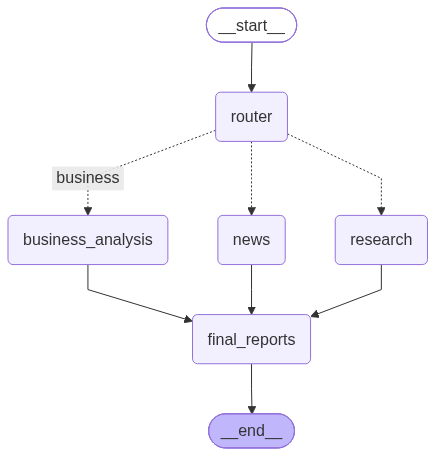

In [49]:
graph

In [50]:
compnay="NVIDIA"
